In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

#Load the data
df = pd.read_csv('data.csv')

#quick overview of the data
print(df.head())
print(df.info())
print(df.describe())

#missing values
print(df.isnull().sum())

#data type and unique values
print(df.dtypes)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

   age  gender education_level  income  experience_years employed
0   22    Male        Bachelor   30000                 1      Yes
1   25  Female          Master   45000                 3      Yes
2   47  Female             PhD   72000                15      Yes
3   35    Male        Bachelor   50000                 8      Yes
4   52    Male          Master   68000                20       No
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               10 non-null     int64
 1   gender            10 non-null     str  
 2   education_level   10 non-null     str  
 3   income            10 non-null     int64
 4   experience_years  10 non-null     int64
 5   employed          10 non-null     str  
dtypes: int64(3), str(3)
memory usage: 612.0 bytes
None
             age       income  experience_years
count  10.000000     10.00000         10.000000
me

Automated Statistical Analysis

In [3]:
import pandas as pd
import numpy as np

def automated_stats():
    stats_dict = {}
    for col in df.select_dtypes(include=[np.number]).columns:
        stats_dict[col] = {
            'mean': df[col].mean(),
            'median': df[col].median(),
            'std': df[col].std(),
            'skewness': df[col].skew(),
            'kurtosis': df[col].kurtosis(),
            'missing': df[col].isnull().sum()
        }
    return pd.DataFrame(stats_dict).T
stats_summary = automated_stats()
print(stats_summary)

                     mean   median           std  skewness  kurtosis  missing
age                  36.8     36.5      9.863513  0.001077 -1.042628      0.0
income            56100.0  55500.0  15183.690080 -0.295571 -1.161346      0.0
experience_years      9.7      9.0      6.481598  0.319073 -1.147165      0.0


Automated Visualization

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

def automated_plots(df, target = None):
    num_cols = df.select_dtypes(include=[np.number]).columns
    
    #Distribution
    for col in num_cols:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.savefig(f'{col}_distribution.png')
        plt.show()
        plt.close()



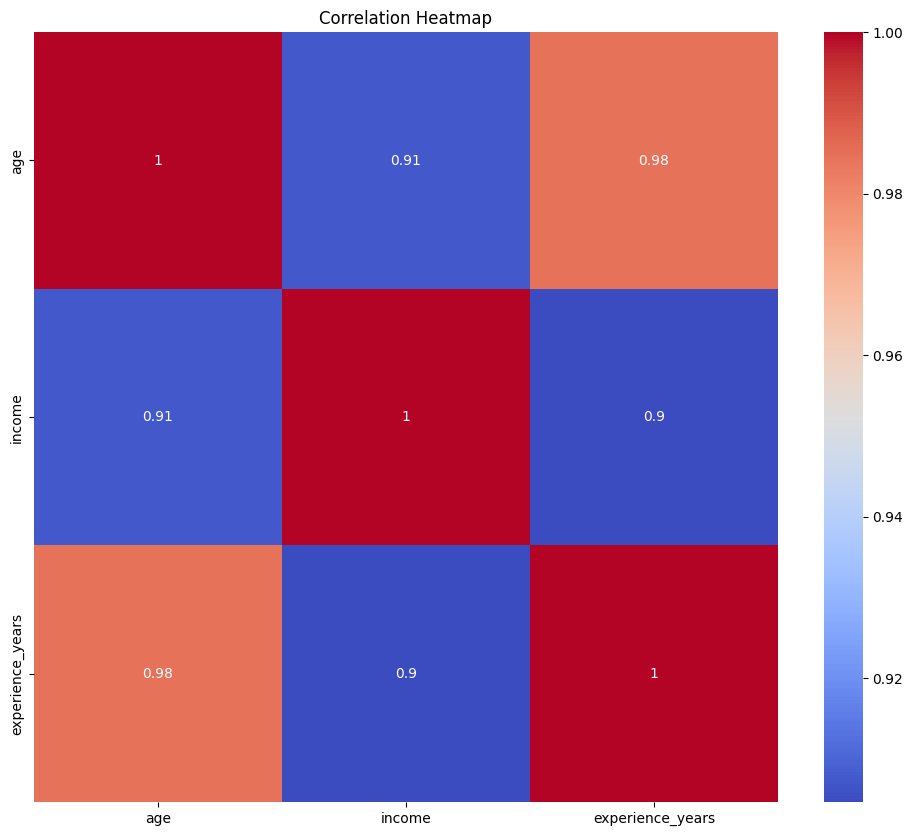

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

#Correlation heatmap
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')  
plt.show()

Using Pandas Profiling

In [ ]:
from pandas.plotting import scatter_matrix
import pandas as pd

#Load data
df = pd.read_csv('data.csv')

#Generate automated EDA report
profile = ProfileReport(df, title="Automated EDA Report", explorative=True)

#Save report
profile.to_file("automated_eda_report.html")

Using Sweetviz

In [32]:
import statsmodels.formula.api as smf

In [26]:
df = pd.read_csv('headbrain11.csv')
df.head()

,Head Size(cm^3),Brain Weight(grams)
0,4512,1530
1,3738,1297
2,4261,1335
3,3777,1282
4,4177,1590


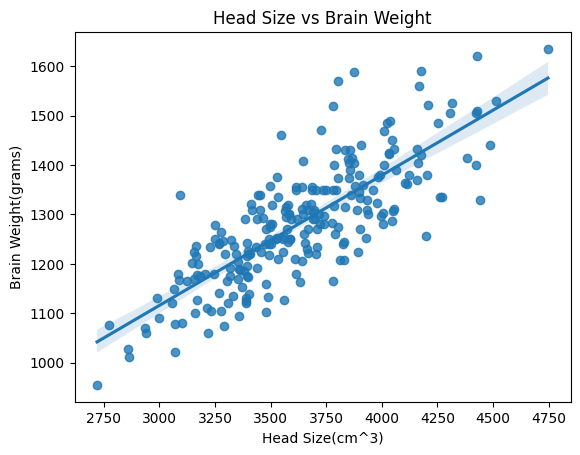

In [27]:
sns.regplot(x='Head Size(cm^3)', y='Brain Weight(grams)', data=df)
plt.title('Head Size vs Brain Weight')
plt.show()

In [35]:
df.columns = ['Head_size', 'Brain_weight']

In [36]:
model = smf.ols(formula='Brain_weight ~ Head_size', data=df).fit()

In [37]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Brain_weight   R-squared:                       0.639
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     416.5
Date:                Mon, 09 Feb 2026   Prob (F-statistic):           5.96e-54
Time:                        11:46:59   Log-Likelihood:                -1350.3
No. Observations:                 237   AIC:                             2705.
Df Residuals:                     235   BIC:                             2711.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    325.5734     47.141      6.906      0.0

In [39]:
import pandas as pd
import statsmodels.api as sm

#Create dataset
data = {
    'Hours_studied': [2, 4, 6, 8, 10],
    'Score': [50, 52, 65, 70, 85]
}

df = pd.DataFrame(data)

#Define variables
x = df['Hours_studied']
y = df['Score']

#Add constant for intercept
x = sm.add_constant(x)

#Fit model
model = sm.OLS(y, x).fit()

#Print summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     54.28
Date:                Mon, 09 Feb 2026   Prob (F-statistic):            0.00517
Time:                        11:56:00   Log-Likelihood:                -12.462
No. Observations:                   5   AIC:                             28.92
Df Residuals:                       3   BIC:                             28.14
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            38.0000      3.961      9.592

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [ ]:
df = pd.read_csv('data.csv') #load data
df.head()                   #first 5 rows
df.tail()                   #last 5v rows         

,age,gender,education_level,income,experience_years,employed
5,46,Female,PhD,75000,18,Yes
6,29,Male,Bachelor,42000,4,Yes
7,41,Female,Master,61000,12,No
8,33,Female,Bachelor,48000,6,Yes
9,38,Male,PhD,70000,10,Yes


In [41]:
from scipy import stats

In [42]:
df.info()
df.shape
df.columns
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               10 non-null     int64
 1   gender            10 non-null     str  
 2   education_level   10 non-null     str  
 3   income            10 non-null     int64
 4   experience_years  10 non-null     int64
 5   employed          10 non-null     str  
dtypes: int64(3), str(3)
memory usage: 612.0 bytes


age                 0
gender              0
education_level     0
income              0
experience_years    0
employed            0
dtype: int64

In [44]:
df['age'].mean()
df['age'].median()
df['age'].std()
df['age'].mode
df['age'].var()
df['age'].min()
df['age'].max()
df['age'].quantile([0.25, 0.5, 0.75])


0.25    30.00
0.50    36.50
0.75    44.75
Name: age, dtype: float64

In [ ]:
df['gender'].value_counts()    #Frequency counts


gender
Male      5
Female    5
Name: count, dtype: int64

In [46]:
df['gender'].value_counts(normalize=True)   #Proportion 

gender
Male      0.5
Female    0.5
Name: proportion, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

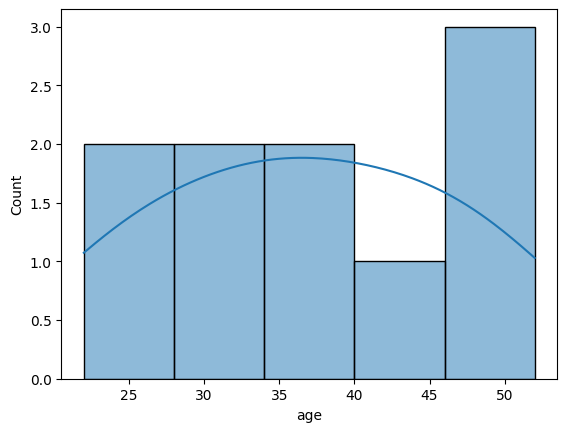

In [47]:
#Numeric
sns.histplot(df['age'], kde=True) #Histogram 


<Axes: xlabel='age'>

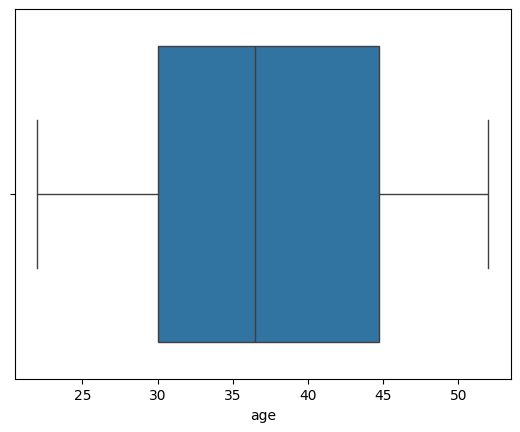

In [48]:
#Numeric
sns.boxplot(x=df['age']) #Boxplot

<Axes: xlabel='gender', ylabel='count'>

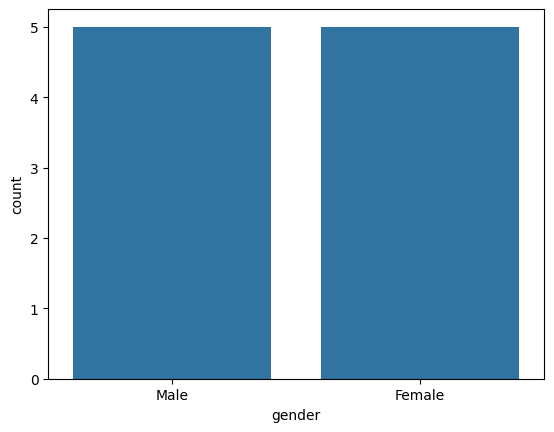

In [49]:
#Categorical
sns.countplot(x='gender', data=df)  #Bar chart

<Axes: xlabel='age', ylabel='income'>

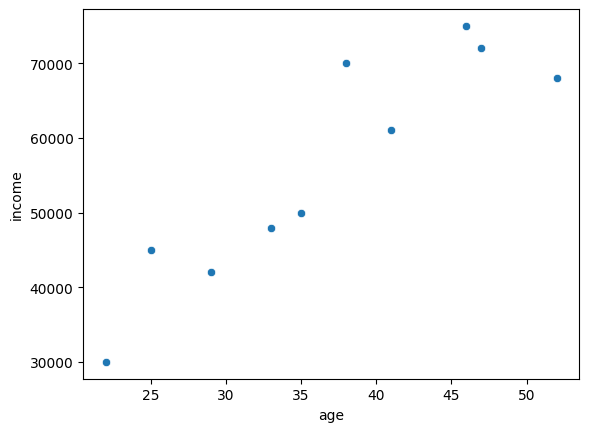

In [51]:
sns.scatterplot(x='age', y='income', data=df)  #Scatter plot

<Axes: xlabel='gender', ylabel='income'>

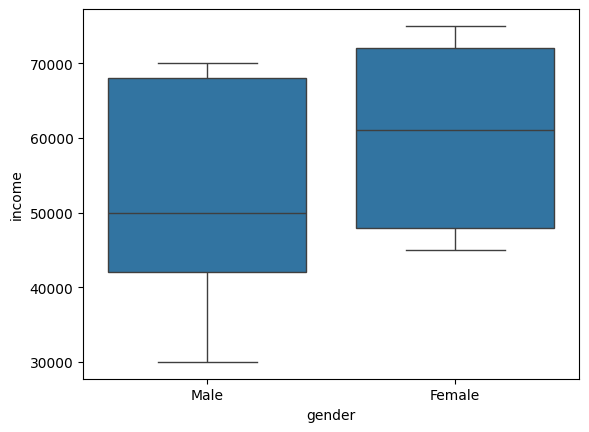

In [52]:
sns.boxplot(x='gender',y='income',data=df) #Boxplot

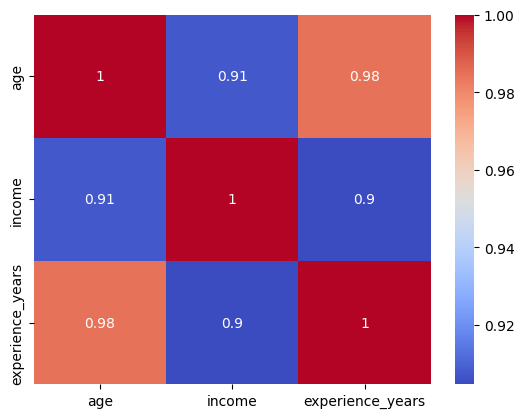

In [53]:
numeric_df = df.select_dtypes(include=[np.number])  #select only numeric columns
corr = numeric_df.corr()  #Correlation matrix
sns.heatmap(corr, annot=True, cmap='coolwarm') #Heatmap
plt.show()